<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/10_priority_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 10  Random Forest Classifier (Priority Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds a Random Forest classifier to predict request priority (HIGH/MEDIUM/LOW), compared against Naive Bayes and Logistic Regression baselines.

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data

In [4]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_prio_train = np.load(f'{processed_dir}/y_prio_train.npy', allow_pickle=True)
y_prio_test = np.load(f'{processed_dir}/y_prio_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Building a pipeline combining vectorisation and classification

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

priority_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1))
])

priority_pipeline.fit(X_train, y_prio_train)

Pipeline(steps=[('vectorizer', CountVectorizer(max_features=1500)),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=0))])

## Predicting the Test set results

In [6]:
y_pred = priority_pipeline.predict(X_test)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_prio_test[:15]})
print(comparison)

Sample predictions vs actual:
   Predicted  Actual
0     MEDIUM  MEDIUM
1       HIGH    HIGH
2     MEDIUM  MEDIUM
3       HIGH    HIGH
4        LOW     LOW
5       HIGH    HIGH
6        LOW     LOW
7     MEDIUM  MEDIUM
8       HIGH    HIGH
9     MEDIUM  MEDIUM
10    MEDIUM  MEDIUM
11       LOW     LOW
12    MEDIUM    HIGH
13       LOW  MEDIUM
14    MEDIUM    HIGH


## Making the Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_prio_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_prio_test, y_pred))

Confusion Matrix:
[[ 4420  2873  5724]
 [  949 19263  3837]
 [ 1531  2442  9837]]

Accuracy: 0.65885682836701


## Classification Report

In [8]:
print(classification_report(y_prio_test, y_pred))

              precision    recall  f1-score   support

        HIGH       0.64      0.34      0.44     13017
         LOW       0.78      0.80      0.79     24049
      MEDIUM       0.51      0.71      0.59     13810

    accuracy                           0.66     50876
   macro avg       0.64      0.62      0.61     50876
weighted avg       0.67      0.66      0.65     50876



## Visualising the Confusion Matrix

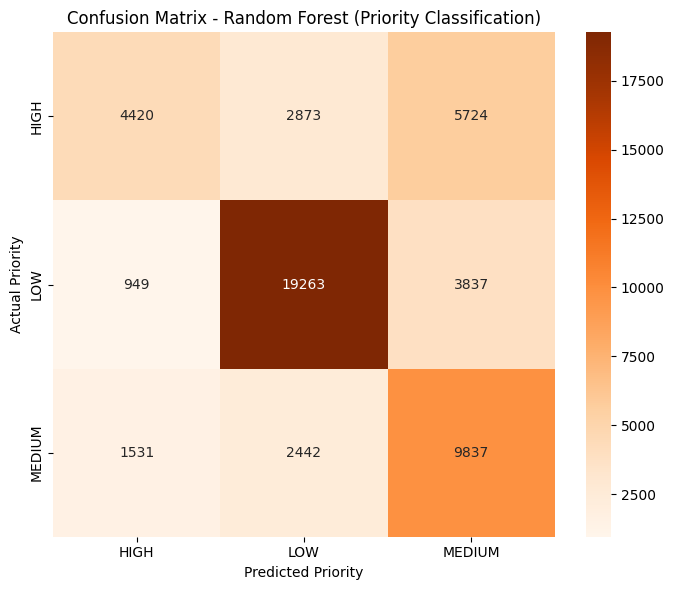

In [9]:
plt.figure(figsize=(7, 6))
unique_labels = sorted(set(y_prio_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Random Forest (Priority Classification)')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Feature importance

Which words contribute most to priority prediction, according to Random Forest.

In [10]:
importances = priority_pipeline.named_steps['classifier'].feature_importances_
feature_names = priority_pipeline.named_steps['vectorizer'].get_feature_names_out()

importance_df = pd.DataFrame({
    'word': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 20 most important words for priority prediction:")
print(importance_df.head(20))

Top 20 most important words for priority prediction:
            word  importance
435      request    0.112334
340          non    0.080185
167     domestic    0.065902
124   collection    0.047625
59           bag    0.038543
413    recycling    0.036378
409         rats    0.026005
234        green    0.023261
214   flytipping    0.022083
568         week    0.021813
84          bulk    0.020219
284        large    0.019339
330     multiple    0.019037
301        liner    0.018964
450          rpb    0.018749
543   unreported    0.017582
60          bags    0.016689
517         team    0.016446
430  replacement    0.013600
505       street    0.013010


## Appending results to the priority comparison file

In [11]:
from sklearn.metrics import f1_score

results_path = '/content/drive/MyDrive/council-classifier/processed/priority_model_results.csv'
results_df = pd.read_csv(results_path)

new_result = {
    'model': 'Random Forest',
    'accuracy': accuracy_score(y_prio_test, y_pred),
    'f1_macro': f1_score(y_prio_test, y_pred, average='macro'),
    'f1_weighted': f1_score(y_prio_test, y_pred, average='weighted')
}

results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
results_df.to_csv(results_path, index=False)

print(results_df)

                 model  accuracy  f1_macro  f1_weighted
0          Naive Bayes  0.627801  0.587242     0.625258
1  Logistic Regression  0.657147  0.607315     0.647002
2        Random Forest  0.658857  0.609522     0.648884
